# Rodent Rollout Analysis

This notebook demonstrates how to:
1. Download a pre-trained rodent model and reference data from HuggingFace
2. Load the model checkpoint and configure the environment
3. Generate a rollout (simulation) of rodent behavior
4. Render and save the rollout as a video
5. Create a timelapse visualization of key frames
6. Analyze joint kinematics by comparing reference motion capture data with the simulated rollout

The analysis helps validate how well the trained policy reproduces natural rodent movement patterns by visualizing both the rendered motion and quantitative joint angle comparisons.

## Imports & Setup

First, we configure the rendering backend and import necessary libraries.

In [24]:
import os
import sys

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Set rendering backend based on platform
# macOS: use glfw (native OpenGL)
# Linux: use osmesa (software rendering) or egl (headless GPU)
if sys.platform == "darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    print("Using macOS with GLFW rendering")
else:
    # Change this to egl if GPU is available on Linux
    os.environ["MUJOCO_GL"] = "egl"
    print("Using Linux with egl rendering")

import mediapy as media
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
import seaborn as sns
import numpy as np
import mujoco
from sklearn.decomposition import PCA
from track_mjx.agent import checkpointing
from track_mjx.analysis import rollout, render
import huggingface_hub as hf_hub


## Some useful helper functions

def get_joint_qpos(model, qposes, joint_name):
    """Get qpos value(s) for a specific joint by name.
    Args:
        model: The Mujoco model.
        qposes: Array of joint position, shape (n_frames, qpos_dim).
        joint_name: Name of the joint to extract.
    Returns:
        The qpos value(s) for the specified joint
    """
    joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
    if joint_id == -1:
        print(f"Joint '{joint_name}' not found!")
        return None

    qpos_addr = model.jnt_qposadr[joint_id]
    joint_type = model.jnt_type[joint_id]

    if joint_type == mujoco.mjtJoint.mjJNT_FREE:
        return qposes[:, qpos_addr : qpos_addr + 7]  # position + quaternion
    elif joint_type == mujoco.mjtJoint.mjJNT_HINGE:
        return qposes[:, qpos_addr]  # single angle
    elif joint_type == mujoco.mjtJoint.mjJNT_BALL:
        return qposes[:, qpos_addr : qpos_addr + 4]  # quaternion
    else:
        return qposes[:, qpos_addr]

Using Linux with egl rendering


## Download Model from HuggingFace

Download the pre-trained rodent model checkpoint from the MIMIC-MJX model repository. This checkpoint contains the trained policy weights and configuration.

In [ ]:
hf_checkpoint_path = "rodent/rodent-analysis/251006_144548_202519"
model_local_dir = Path.cwd().parent / "model_checkpoints"
# Download model from model repo
model_download_dir = hf_hub.snapshot_download(
    repo_id="talmolab/MIMIC-MJX",
    repo_type="model",  # download from model repo
    allow_patterns=hf_checkpoint_path + "/*",  # path with model id
    local_dir=model_local_dir,
)
print(f"Downloaded model to {model_download_dir}")

## Download Reference Data

Download the rodent reference clips dataset that contains the motion capture data used for training and evaluation.

In [ ]:
hf_data_path = "data/rodent/rodent_reference_clips.h5"
# Download data from dataset repo
data_download_dir = hf_hub.hf_hub_download(
    repo_id="talmolab/MIMIC-MJX",
    repo_type="dataset",  # download from dataset repo
    filename=hf_data_path,  # dataset name
    local_dir=Path.cwd().parent,
)
print(f"Downloaded data to {data_download_dir}")

## Load Checkpoint and Configure

Load the checkpoint and update the configuration with the downloaded data path.

In [ ]:
# replace with your checkpoint path
ckpt_path = model_local_dir / hf_checkpoint_path

ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path)
cfg = ckpt["cfg"]

# Update the data path to the downloaded data
cfg.data_path = Path(data_download_dir)

In [ ]:
# TEMP: add max_start_frames to cfg to support older checkpoints
cfg.env_config.env_args.max_start_frame = 40

## Create Environment and Rollout Generator

Set up the simulation environment, load the inference function from the trained policy, and create a rollout generator that will produce simulations.

In [37]:
env = rollout.create_environment(cfg)
inference_fn = checkpointing.load_inference_fn(cfg, ckpt["policy"])
generate_rollout = rollout.create_rollout_generator(
    cfg,
    env,
    inference_fn,
    log_activations=True,
    log_metrics=False,
    log_sensor_data=False,
)

Converting to torque actuators
Rescaling body tree with scale factor 0.9


/home/talmolab/anaconda3/envs/track_mjx/lib/python3.12/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


## Generate Rollout

Generate a single rollout using clip index 22 from the reference data. This will simulate the rodent's behavior based on the trained policy. Feel free to change the clip index to visualize different behaviors in this dataset.

> **Note:** The first time you run this cell, it may take up to 2 minutes to compile the model with JAX, depending on your hardware. Subsequent runs will be much faster.


In [38]:
single_rollout = generate_rollout(clip_idx=22)

## Render and Save Video

Render the rollout as video frames and save it as an MP4 file. The video will be saved in the checkpoint directory.

In [11]:
frames, realtime_framerate = render.render_rollout(
    cfg,
    single_rollout,
    height=480,
    width=640,
)

# save the video to disk
media.write_video(Path(ckpt_path) / "rollout.mp4", frames, fps=realtime_framerate * 2)
# media.show_video(frames, fps=realtime_framerate)

MuJoCo Rendering with Ghost Model...
Rendering every 1 steps; realtime fps: 100


100%|██████████| 500/500 [00:00<00:00, 521.92it/s]


## Create Timelapse Visualization

Sample every 100th frame from the video and display the first 4 frames in a single row. This provides a quick overview of the rodent's behavior progression throughout the rollout.

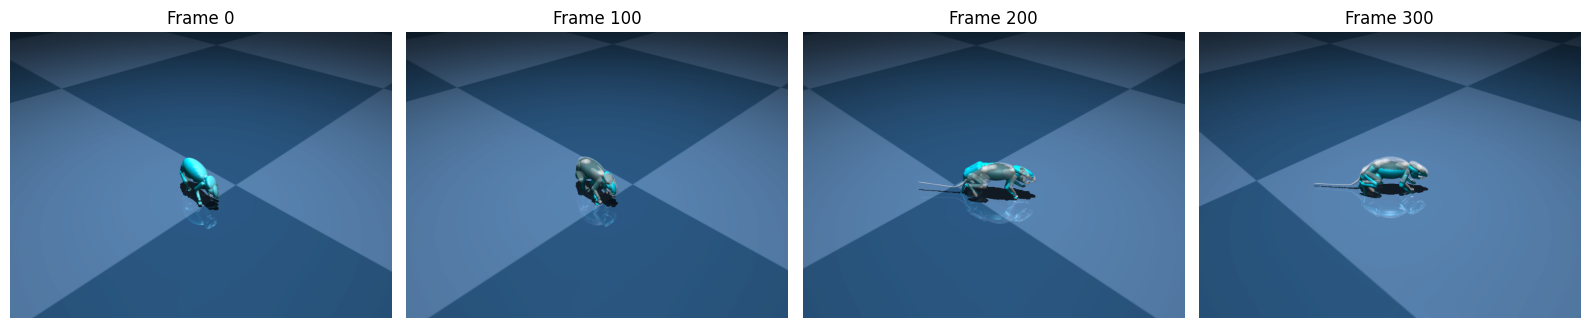

In [15]:
# Sample every 50th frame and take only 4 frames
sampled_frames = frames[::100][:4]
num_frames = len(sampled_frames)

# Fixed grid dimensions: 1 row, 4 columns
cols = 4
rows = 1

# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4))
axes = axes.flatten()

# Plot each sampled frame
for idx, frame in enumerate(sampled_frames):
    axes[idx].imshow(frame)
    axes[idx].set_title(f"Frame {idx * 100}")
    axes[idx].axis("off")

# Hide any unused subplots
for idx in range(num_frames, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(Path(ckpt_path) / "rollout_timelapse.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualize Rollout Kinematic Statistics

This section analyzes the joint kinematics by comparing the reference motion capture data (STAC Registration) with the simulated rollout (Track Replay). 

We'll plot the joint angles over time for key upper body joints (shoulders and elbows) to assess how accurately the trained policy reproduces the reference motion. The red shaded area highlights the differences between reference and simulated trajectories, providing a visual measure of tracking accuracy.

In [26]:
single_rollout.keys()

dict_keys(['ctrl', 'qposes_ref', 'qposes_rollout', 'state_rewards'])

### Joint Angle Comparison

Extract joint positions (qpos) from both the reference and rollout data, then plot the joint angles over time. The visualization includes:

- **Orange line**: STAC Registration (ground truth motion capture)
- **Blue line**: Track Replay (simulated rollout from trained policy)
- **Red shaded area**: Magnitude of difference between reference and rollout

All subplots share the same y-axis scale for easier comparison across joints. Joint angles are displayed in degrees for intuitive interpretation.

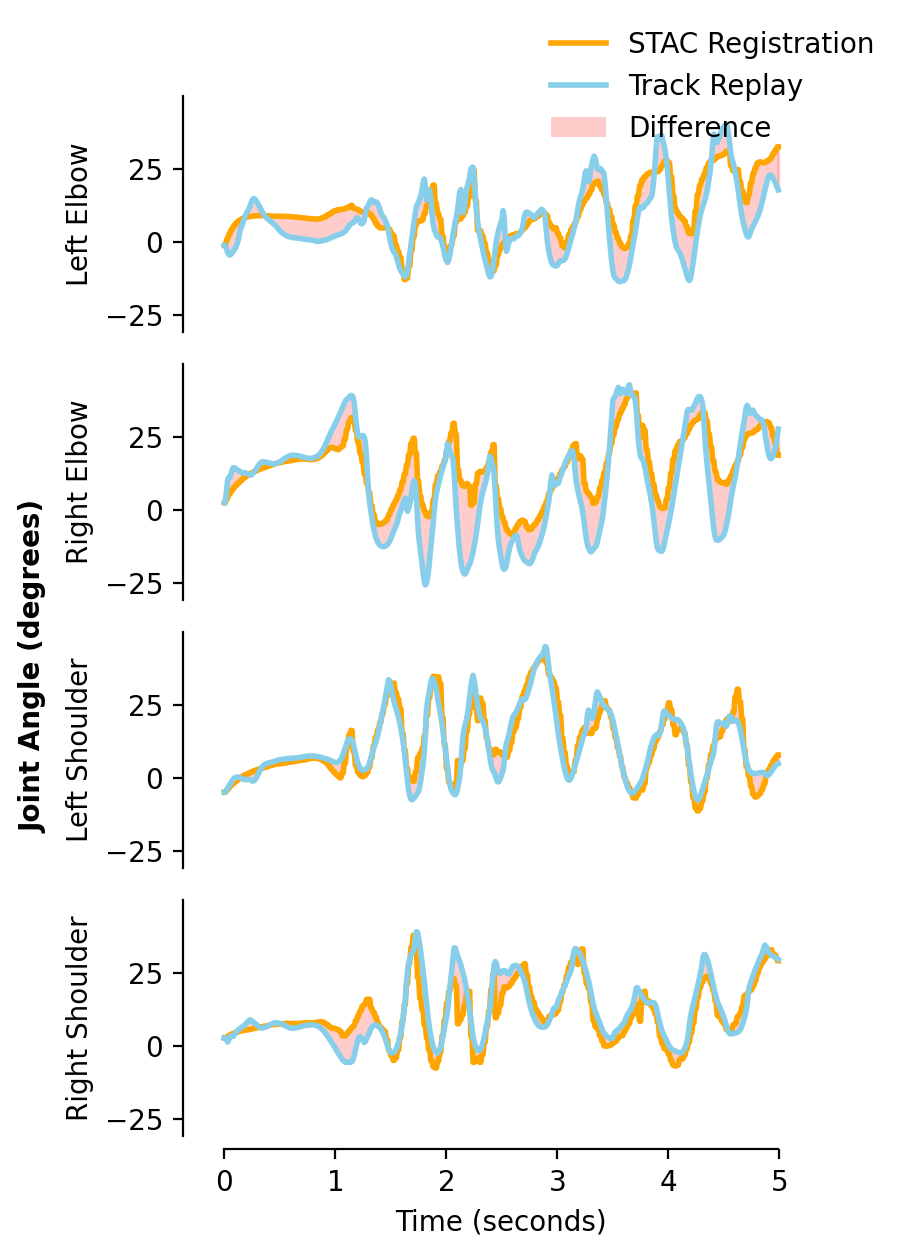

In [36]:
qposes_ref = single_rollout["qposes_ref"]
qposes_rollout = single_rollout["qposes_rollout"]
# Create subplots for joint angle comparison
joint_names = ["elbow_L", "elbow_R", "shoulder_L", "shoulder_R"]
joint_labels = ["Left Elbow", "Right Elbow", "Left Shoulder", "Right Shoulder"]

# Set up the subplots
fig, axes = plt.subplots(len(joint_names), 1, figsize=(4, 6), sharex=True)

# First pass: collect all angle data to determine global y-axis limits
all_ref_angles = []
all_rollout_angles = []

for joint_name in joint_names:
    ref_angles = get_joint_qpos(env.sys.mj_model, qposes_ref, f"{joint_name}")
    rollout_angles = get_joint_qpos(env.sys.mj_model, qposes_rollout, f"{joint_name}")

    # Convert from radians to degrees
    ref_angles_deg = np.degrees(ref_angles)
    rollout_angles_deg = np.degrees(rollout_angles)

    all_ref_angles.extend(ref_angles_deg)
    all_rollout_angles.extend(rollout_angles_deg)

# Calculate global y-axis limits with some padding
all_angles = all_ref_angles + all_rollout_angles
y_min = np.min(all_angles) - 5  # Add 5 degree padding
y_max = np.max(all_angles) + 5  # Add 5 degree padding

# Plot each joint in its own subplot
for i, (joint_name, joint_label) in enumerate(zip(joint_names, joint_labels)):
    # Get joint angles for both reference and rollout
    ref_angles = get_joint_qpos(env.sys.mj_model, qposes_ref, f"{joint_name}")
    rollout_angles = get_joint_qpos(env.sys.mj_model, qposes_rollout, f"{joint_name}")

    # Convert from radians to degrees
    ref_angles_deg = np.degrees(ref_angles)
    rollout_angles_deg = np.degrees(rollout_angles)

    # Create time axis
    time_steps = np.arange(len(ref_angles))
    # Convert time steps to seconds (100 Hz = 0.01 seconds per step)
    time_seconds = time_steps * 0.01

    # Plot using seaborn style with solid lines for both
    sns.lineplot(
        x=time_seconds,
        y=ref_angles_deg,
        ax=axes[i],
        color="orange",
        label="STAC Registration",
        linewidth=2,
    )
    sns.lineplot(
        x=time_seconds,
        y=rollout_angles_deg,
        ax=axes[i],
        color="skyblue",
        label="Track Replay",
        linewidth=2,
    )

    # Highlight differences by filling the area between lines
    axes[i].fill_between(
        time_seconds,
        ref_angles_deg,
        rollout_angles_deg,
        alpha=0.2,
        color="red",
    )

    # Customize subplot
    axes[i].set_ylabel(joint_label)

    # Set consistent y-axis limits for all subplots
    axes[i].set_ylim(y_min, y_max)

    # Set informative y-axis ticks
    # Create ticks at nice intervals that include both positive and negative values
    tick_range = y_max - y_min
    if tick_range > 80:
        # For large ranges, use 25-degree intervals
        tick_interval = 25
    elif tick_range > 40:
        # For medium ranges, use 20-degree intervals
        tick_interval = 20
    else:
        # For small ranges, use 10-degree intervals
        tick_interval = 10

    # Generate ticks from the lowest multiple of tick_interval to the highest
    tick_start = int(np.floor(y_min / tick_interval)) * tick_interval
    tick_end = int(np.ceil(y_max / tick_interval)) * tick_interval
    y_ticks = np.arange(tick_start, tick_end + tick_interval, tick_interval)

    # Filter ticks to only show those within our y-limits
    y_ticks = y_ticks[(y_ticks >= y_min) & (y_ticks <= y_max)]
    axes[i].set_yticks(y_ticks)

    # Set informative x-axis ticks in seconds
    max_time = time_seconds[-1]
    if max_time <= 2:
        # For short sequences, use 0.5 second intervals
        x_tick_interval = 0.5
    elif max_time <= 5:
        # For medium sequences, use 1 second intervals
        x_tick_interval = 1.0
    else:
        # For longer sequences, use 2 second intervals
        x_tick_interval = 2.0

    x_ticks = np.arange(0, max_time + x_tick_interval, x_tick_interval)
    axes[i].set_xticks(x_ticks)

    # Remove grid and customize spines
    axes[i].grid(False)
    # For all but the last subplot: remove bottom spine and x-axis ticks
    if i < len(joint_names) - 1:
        sns.despine(ax=axes[i], top=True, right=True, bottom=True, left=False)
        axes[i].tick_params(bottom=False, labelbottom=False)
        # Add gap at bottom of left spine
        axes[i].spines["left"].set_position(("outward", 5))
    else:
        # For the last subplot: keep bottom spine and x-axis
        sns.despine(ax=axes[i], top=True, right=True, bottom=False, left=False)
        # Set x-axis spine to stop at the maximum time
        axes[i].spines["bottom"].set_bounds(0, max_time)
        # Add gap between left and bottom spines
        axes[i].spines["left"].set_position(("outward", 5))
        axes[i].spines["bottom"].set_position(("outward", 5))

    # Remove legends from all subplots
    if axes[i].get_legend():
        axes[i].get_legend().remove()

# Add shared y-axis label
fig.text(
    -0.02,
    0.5,
    "Joint Angle (degrees)",
    va="center",
    rotation="vertical",
    fontweight="bold",
)

# Add manual legend at the upper right with vertical stacking
from matplotlib.patches import Patch

legend_elements = [
    plt.Line2D([0], [0], color="orange", lw=2, label="STAC Registration"),
    plt.Line2D([0], [0], color="skyblue", lw=2, label="Track Replay"),
    Patch(facecolor="red", alpha=0.2, label="Difference"),
]
fig.legend(
    handles=legend_elements,
    loc="upper right",
    ncol=1,  # Changed from 3 to 1 for vertical stacking
    frameon=False,
    bbox_to_anchor=(1.08, 1.05),  # Fine-tune position
)

# Set common x-axis label
axes[-1].set_xlabel("Time (seconds)")

# Adjust layout to accommodate shared y-label and legend
plt.subplots_adjust(left=0.12, top=0.92)
plt.tight_layout()
plt.show()

In [41]:
single_rollout["activations"].keys()

dict_keys(['decoder', 'egocentric_obs', 'encoder', 'intention', 'traj_obs'])

### PCA Visualization of Intention Space

Apply PCA to reduce the high-dimensional intention space to 2 principal components. This visualization helps us understand:

- **Trajectory through latent space**: How the policy's internal representation evolves over time
- **Clustering patterns**: Whether different behavioral phases occupy distinct regions
- **Temporal dynamics**: The structure and smoothness of the policy's decision-making process

We'll color-code the trajectory by time to show the temporal progression through the intention space.

## Neural Network Activation Analysis

This section explores the internal representations learned by the policy network. We'll use Principal Component Analysis (PCA) to visualize the high-dimensional activation space in 2D, revealing the latent structure of the policy's decision-making process throughout the rollout.

Intention activation shape: (499, 60)
(timesteps, feature_dimensions)

Explained variance ratio:
PC1: 0.302
PC2: 0.165
Total: 0.467


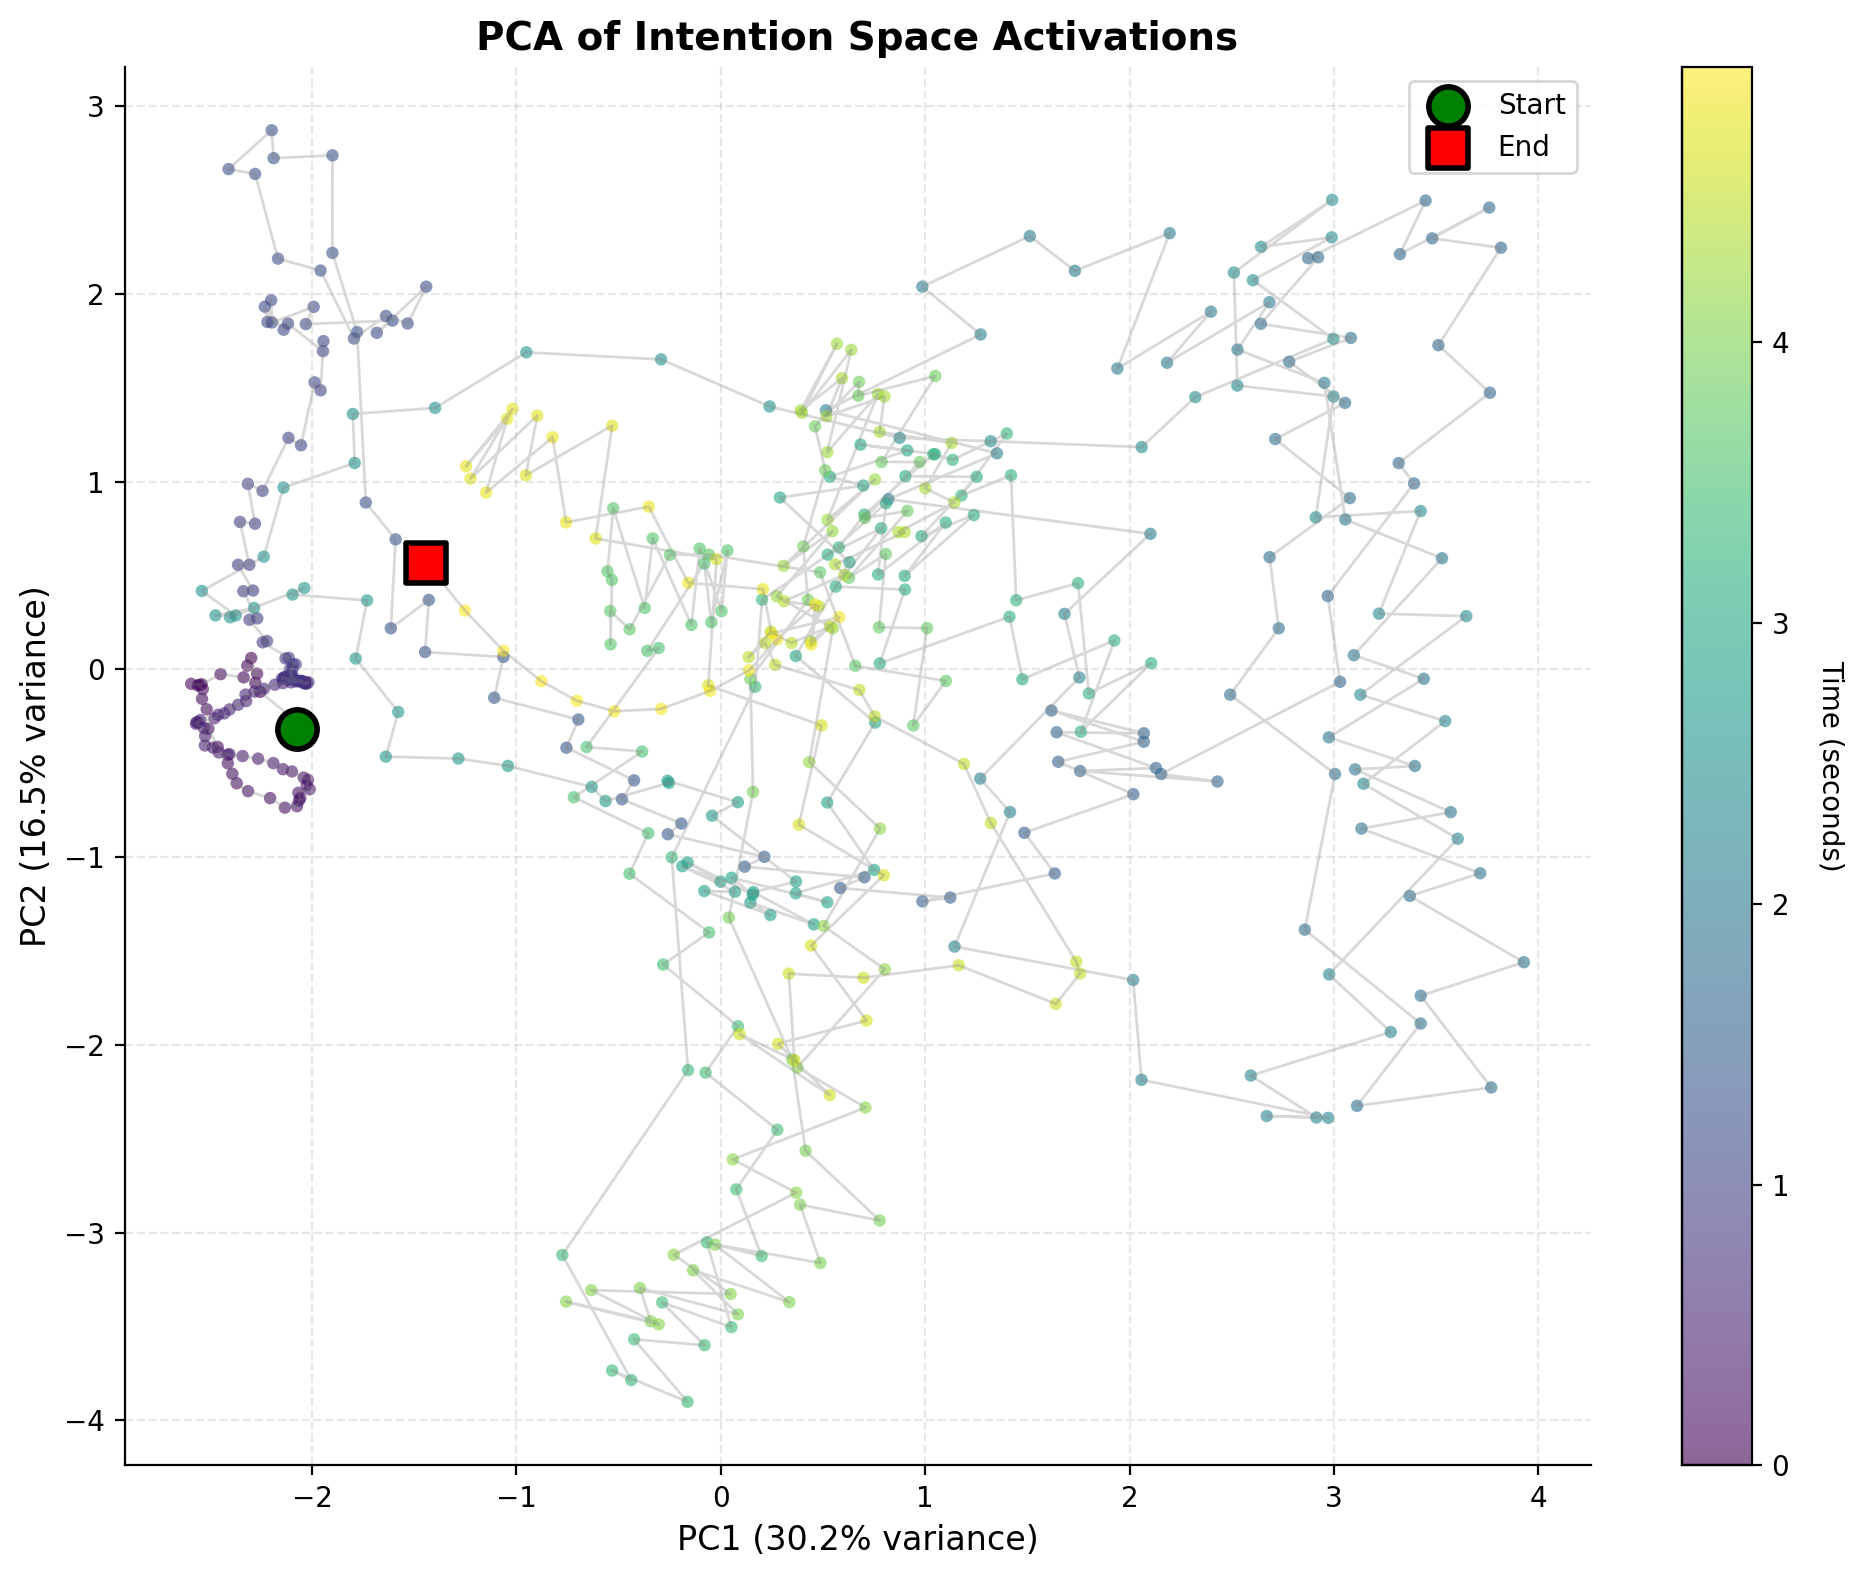

In [47]:
from sklearn.decomposition import PCA

# Extract intention activations (the latent representation before the policy head)
intention_activations = single_rollout["activations"]["intention"]
print(f"Intention activation shape: {intention_activations.shape}")
print(f"(timesteps, feature_dimensions)")

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
intention_pca = pca.fit_transform(intention_activations)

# Print explained variance
print(f"\nExplained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

# Create time-based colormap
time_steps = np.arange(len(intention_pca))
time_seconds = time_steps * 0.01

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectory with time-based color gradient
scatter = ax.scatter(
    intention_pca[:, 0],
    intention_pca[:, 1],
    c=time_seconds,
    cmap="viridis",
    s=20,
    alpha=0.6,
    edgecolors="none",
)

# Add trajectory line to show temporal progression
ax.plot(
    intention_pca[:, 0], intention_pca[:, 1], "gray", alpha=0.3, linewidth=1, zorder=1
)

# Mark start and end points
ax.scatter(
    intention_pca[0, 0],
    intention_pca[0, 1],
    c="green",
    s=200,
    marker="o",
    edgecolors="black",
    linewidths=2,
    label="Start",
    zorder=3,
)
ax.scatter(
    intention_pca[-1, 0],
    intention_pca[-1, 1],
    c="red",
    s=200,
    marker="s",
    edgecolors="black",
    linewidths=2,
    label="End",
    zorder=3,
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Time (seconds)", rotation=270, labelpad=20)

# Labels and title
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.set_title("PCA of Intention Space Activations", fontsize=14, fontweight="bold")
ax.legend(loc="best", frameon=True, fancybox=True)

# Style
ax.grid(True, alpha=0.3, linestyle="--")
sns.despine()

plt.tight_layout()
plt.savefig(Path(ckpt_path) / "intention_pca.png", dpi=150, bbox_inches="tight")
plt.show()